## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint


# output directories
import os
os.makedirs("./figures", exist_ok=True)

## Model

In [2]:
# ----------------------------------------------------
# Parameters (simplified mechanotransduction model)
# ----------------------------------------------------

params = {

    # Fibroblast recruitment
    'lambda_I': 1.2,      # inflammation driven recruitment
    'lambda_S': 1.0,      # stiffness driven recruitment
    'Fmax': 1.0,          # crowding limit

    'dF': 0.25,           # fibroblast death rate
    'kFM': 0.4,           # fibroblast -> myofibroblast conversion

    # Myofibroblast dynamics
    'beta': 1.2,          # stiffness amplification
    'dM': 0.3,            # myofibroblast decay

    # Collagen dynamics
    'kC': 0.6,            # collagen production
    'dC': 0.02,           # collagen degradation

    # Stiffness scaling
    'ks': 1.5,             # collagen -> stiffness conversion
    'S0': 0.05,            # baseline stiffness
    'ks': 1.5,             # collagen -> stiffness conversion --- IGNORE ---
    'beta': 1.7,           # stiffness feedback strength

    # MMP9 dynamics
    'kP_F': 0.3,    # production from fibroblasts
    'kP_I': 0.6,    # inflammation-driven production
    'dP': 0.4       # MMP9 decay

    
    
}

# ----------------------------------------------------
# Inflammatory signal
# ----------------------------------------------------

def get_pulse(
        time,
        pulse_times=None,
        small_amp=None,
        width=None
):

    # Initial MI spike
    I = np.exp(-0.4 * time)

    # Optional repeated pulses
    if pulse_times is not None and small_amp is not None and width is not None:
        for tp in pulse_times:
            I += small_amp * np.exp(-((time - tp)**2) / (2 * width**2))

    return I


# ----------------------------------------------------
# ODE System
# ----------------------------------------------------

def cardiac_bistable_ode(y, t, p, pulse_times=None, small_amp=None, width=None):

    F, M, C, P = y

    # inflammatory signal
    I = get_pulse(t, pulse_times, small_amp, width)

    # matrix stiffness from collagen
    S = p['ks'] * C

    # fibroblasts
    dFdt = (
        (p['lambda_I'] * I + p['lambda_S'] * S) * F * (1 - F/p['Fmax'])
        - p['dF'] * F
        - p['kFM'] * F
    )

    # myofibroblasts
    dMdt = (
        p['kFM'] * F
        + p['beta'] * S * M
        - p['dM'] * M
    )

    # collagen
    dCdt = (
        p['kC'] * M
        - p['dC'] * C
    )

    # MMP9 dynamics
    dPdt = (
        p['kP_F'] * F
        + p['kP_I'] * I
        - p['dP'] * P
    )

    return [dFdt, dMdt, dCdt, dPdt]

def normalize(x):
    x = np.array(x)
    return (x - np.min(x)) / (np.max(x) - np.min(x))

def get_stiffness(collagen_raw, params):
    stiffness = params['S0'] + params['ks'] * (collagen_raw ** params['beta'])
    stiffness_norm = normalize(stiffness)
    return stiffness_norm

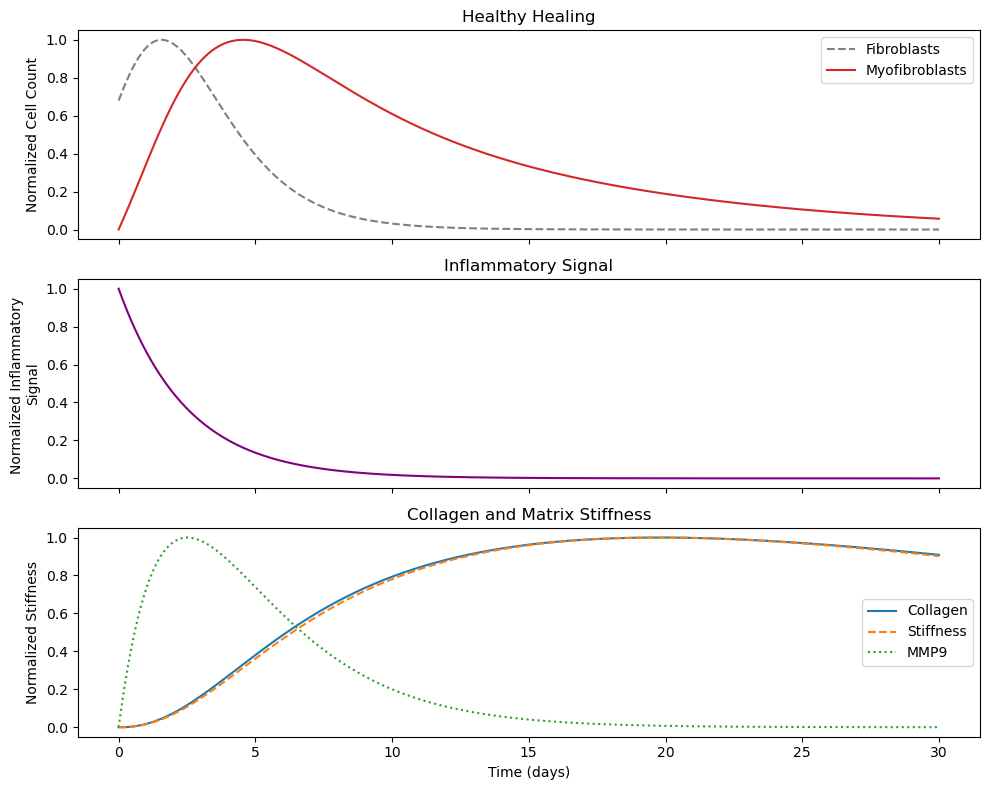

In [ ]:
y0 = [0.01, 0.0, 0.01, 0.0]
t = np.linspace(0, 30, 1000)
def run_simulation(pulse_times=None, amp=None, width=None):

    results = odeint(
        cardiac_bistable_ode,
        y0,
        t,
        args=(params, pulse_times, amp, width)
    )

    F = results[:,0]
    M = results[:,1]
    C = results[:,2]
    P = results[:,3]

    S = params['ks'] * C + (params['S0'] + params['ks'] * C) ** params['beta']
    S = normalize(S) 
    I = np.array([get_pulse(tt, pulse_times, amp, width) for tt in t])

    return F, M, C, S, I, P 

F, M, C, S, I, P = run_simulation()

plt.figure(figsize=(10,8))

plt.subplot(3,1,1)
plt.plot(t, normalize(F), '--', label="Fibroblasts", color='gray')
plt.plot(t, normalize(M), label="Myofibroblasts", color='tab:red')
plt.ylabel("Normalized Cell Count")
plt.legend()
plt.title("Healthy Healing")
plt.tick_params(axis='x', labelbottom=False)

plt.subplot(3,1,2)
plt.plot(t, normalize(I), color="purple")
plt.ylabel("Normalized Inflammatory \nSignal")
plt.title("Inflammatory Signal")
plt.tick_params(axis='x', labelbottom=False)

plt.subplot(3,1,3)
plt.plot(t, normalize(C), label="Collagen")
plt.plot(t, normalize(S), '--', label="Stiffness")
plt.plot(t, normalize(P), ':', label="MMP9")
plt.ylabel("Normalized Stiffness")
plt.title("Collagen and Matrix Stiffness")
plt.xlabel("Time (days)")
plt.legend()


plt.tight_layout()
plt.savefig('./figures/fig_healthy_healing.png', dpi=300, bbox_inches='tight')
plt.show()

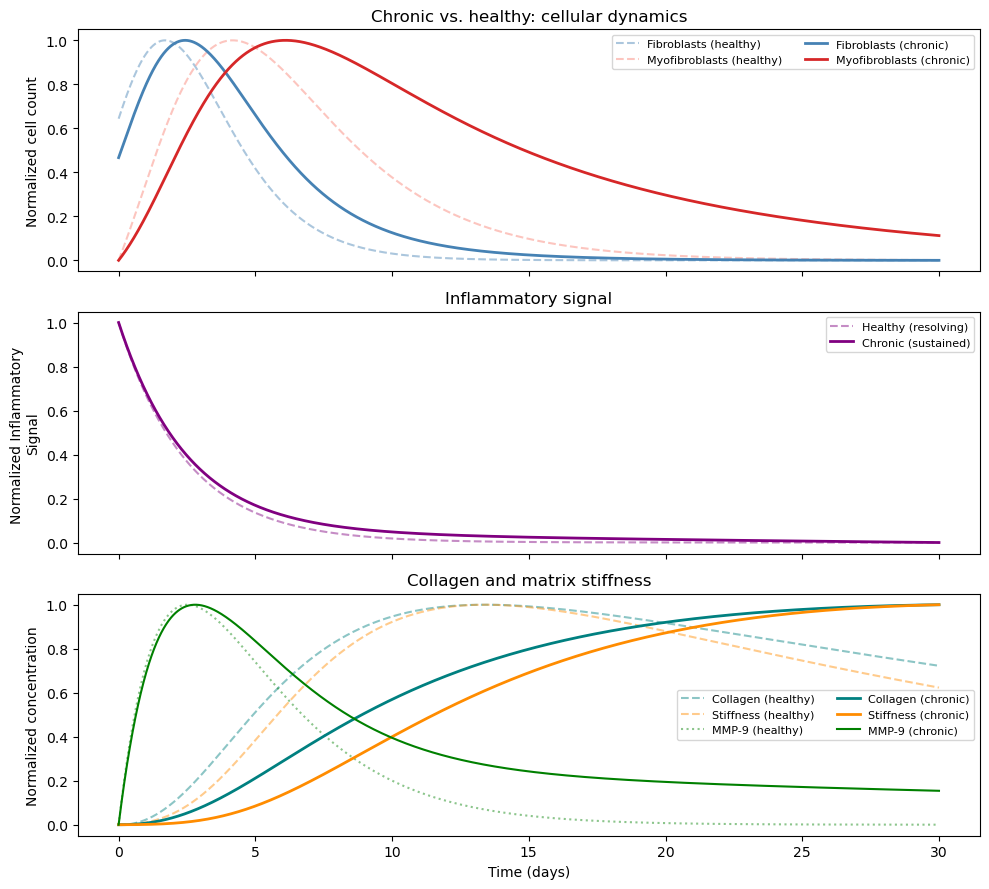

In [5]:
# Helpers
def normalize(x):
    x = np.array(x)
    xmin, xmax = np.min(x), np.max(x)
    if xmax - xmin < 1e-12:
        return np.zeros_like(x)
    return (x - xmin) / (xmax - xmin)


# Parameter sets

params_healthy = {
    'lambda_I':    1.2,
    'lambda_S':    1.0,
    'Fmax':        1.0,
    'dF':          0.25,
    'kFM':         0.4,
    'dM':          0.3,
    'kC':          0.6,
    'dC':          0.02,
    'ks':          1.5,
    'S0':          0.05,
    'beta_stiff':  1.7,
    'kP_F':        0.3,
    'kP_I':        0.6,
    'dP':          0.4,
    # stiffness -> M feedback (Hill saturation prevents runaway)
    'kSM':         0.3,
    'KS':          2.0,
}

# Chronic bistable params — represents a patient whose
# mechanotransduction feedback has been tipped past the bistable
# threshold by persistent low-level inflammation.
# Key changes vs healthy:
#   kSM higher  -> stronger stiffness->myofibroblast feedback
#   KS lower    -> myofibroblasts activate at lower stiffness
#   dC lower    -> collagen accumulates (reduced MMP activity)
#   dM lower    -> myofibroblasts persist (reduced apoptosis)
#   kC higher   -> more collagen secreted per myofibroblast
params_chronic = {
    **params_healthy,
    'lambda_S':   1.4,
    'dC':         0.007,
    'dM':         0.20,
    'kC':         0.85,
    'kSM':        0.8,   # primary bistable lever
    'KS':         1.5,
}


# Inflammatory signals

def I_healthy(time):
    """Standard post-MI spike that resolves within ~10 days."""
    return np.exp(-0.4 * time)


def I_chronic(time):
    """
    Persistent low-level inflammation: initial MI spike plus a
    slowly decaying sustained component mimicking chronic immune
    activation (e.g. repeated small ischaemic events, cardiometabolic
    co-morbidities).
    """
    return np.exp(-0.4 * time) + 0.12 * np.exp(-0.02 * time)


# ODE system

def make_ode(p, I_func):
    """
    Returns the ODE function for a given parameter set and
    inflammatory signal. Uses Hill-saturating stiffness feedback
    on the myofibroblast equation to prevent numerical runaway
    while preserving bistable dynamics.
    """
    def ode(y, time):
        F, M, C, P = [max(v, 0.0) for v in y]
        I = I_func(time)

        # stiffness from collagen (power-law, clamped for numerics)
        C_safe = min(C, 200.0)
        S = p['S0'] + p['ks'] * (C_safe ** p['beta_stiff'])

        crowding = min(F / p['Fmax'], 0.99)

        dFdt = (
            (p['lambda_I'] * I + p['lambda_S'] * S) * F * (1 - crowding)
            - p['dF'] * F
            - p['kFM'] * F
        )

        # Hill-saturating stiffness->M term: kSM * S/(S+KS) * M
        # saturates at kSM*M rather than growing as S*M
        S_feedback = p['kSM'] * (S / (S + p['KS'])) * M

        dMdt = p['kFM'] * F + S_feedback - p['dM'] * M
        dCdt = p['kC'] * M - p['dC'] * C
        dPdt = p['kP_F'] * F + p['kP_I'] * I - p['dP'] * P

        return [dFdt, dMdt, dCdt, dPdt]
    return ode


# Run simulations

y0 = [0.01, 0.0, 0.01, 0.0]
t  = np.linspace(0, 30, 3000)

res_h = odeint(make_ode(params_healthy, I_healthy), y0, t,
               rtol=1e-9, atol=1e-11)
res_c = odeint(make_ode(params_chronic,  I_chronic), y0, t,
               rtol=1e-9, atol=1e-11)


def unpack(res, p, I_func):
    F, M, C, P = res[:,0], res[:,1], res[:,2], res[:,3]
    C_safe = np.minimum(C, 200.0)
    S = p['S0'] + p['ks'] * (C_safe ** p['beta_stiff'])
    I = np.array([I_func(tt) for tt in t])
    return F, M, C, P, S, I


F_h, M_h, C_h, P_h, S_h, I_h = unpack(res_h, params_healthy, I_healthy)
F_c, M_c, C_c, P_c, S_c, I_c = unpack(res_c, params_chronic,  I_chronic)


# Plot
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

# panel 1 — cells
axes[0].plot(t, normalize(F_h), '--', color='steelblue', alpha=0.45,
             label="Fibroblasts (healthy)")
axes[0].plot(t, normalize(M_h), '--', color='salmon',    alpha=0.45,
             label="Myofibroblasts (healthy)")
axes[0].plot(t, normalize(F_c), '-',  color='steelblue', lw=2,
             label="Fibroblasts (chronic)")
axes[0].plot(t, normalize(M_c), '-',  color='tab:red',   lw=2,
             label="Myofibroblasts (chronic)")
axes[0].set_ylabel("Normalized cell count")
axes[0].set_title("Chronic vs. healthy: cellular dynamics")
axes[0].legend(fontsize=8, ncol=2)

# panel 2 — inflammatory signal
axes[1].plot(t, normalize(I_h), '--', color='purple', alpha=0.45,
             label="Healthy (resolving)")
axes[1].plot(t, normalize(I_c), '-',  color='purple', lw=2,
             label="Chronic (sustained)")
axes[1].set_ylabel("Normalized Inflammatory \nSignal")
axes[1].set_title("Inflammatory signal")
axes[1].legend(fontsize=8)

# panel 3 — ECM
axes[2].plot(t, normalize(C_h), '--', color='teal',       alpha=0.45,
             label="Collagen (healthy)")
axes[2].plot(t, normalize(S_h), '--', color='darkorange',  alpha=0.45,
             label="Stiffness (healthy)")
axes[2].plot(t, normalize(P_h), ':', color='green',      alpha=0.45,
             label="MMP-9 (healthy)")
axes[2].plot(t, normalize(C_c), '-',  color='teal',        lw=2,
             label="Collagen (chronic)")
axes[2].plot(t, normalize(S_c), '-',  color='darkorange',  lw=2,
             label="Stiffness (chronic)")
axes[2].plot(t, normalize(P_c), '-',  color='green',       lw=1.5,
             label="MMP-9 (chronic)")
axes[2].set_ylabel("Normalized concentration")
axes[2].set_title("Collagen and matrix stiffness")
axes[2].set_xlabel("Time (days)")
axes[2].legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig('./figures/fig_chronic_inflammation.png', dpi=300, bbox_inches='tight')
plt.show()

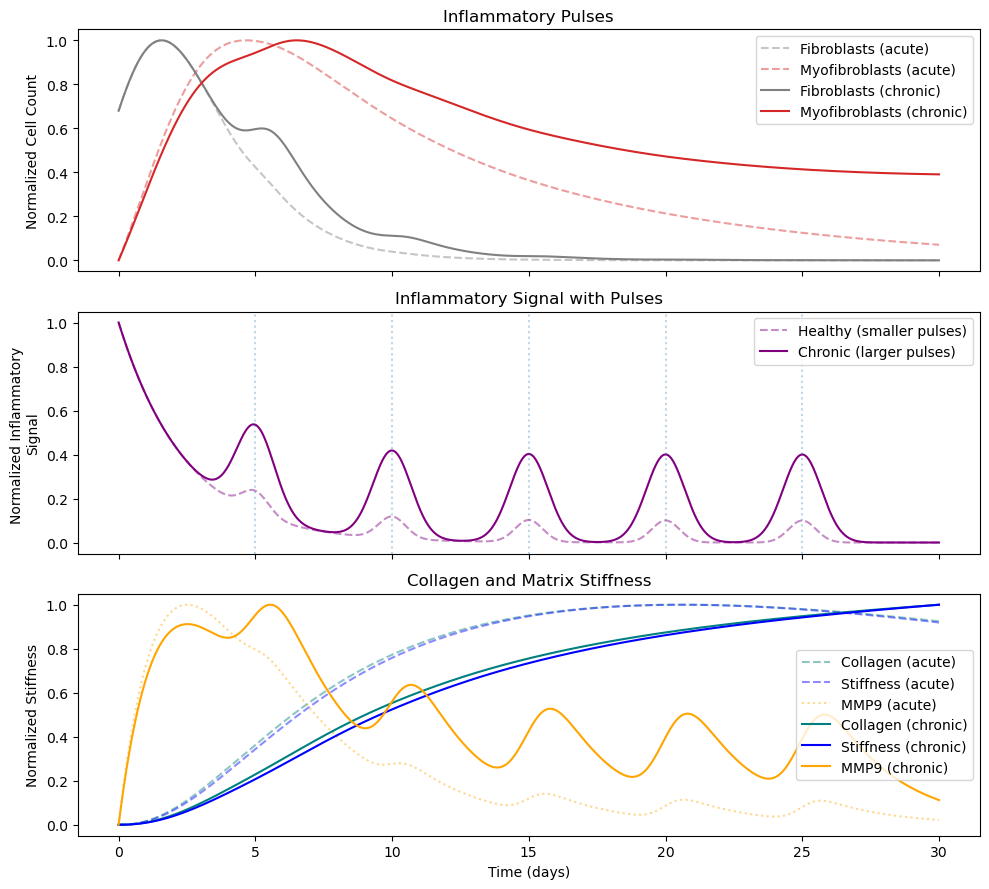

In [6]:
pulse_times = [5,10,15,20,25]

F, M, C, S, I, P = run_simulation(
    pulse_times=pulse_times,
    amp=0.1,
    width=0.5
)
F_chron, M_chron, C_chron, S_chron, I_chron, P_chron = run_simulation(
    pulse_times=pulse_times,
    amp=0.4,
    width=0.7
)

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)


axes[0].plot(t, normalize(F),'--', label="Fibroblasts (acute)", color='gray', alpha=0.45)
axes[0].plot(t, normalize(M), "--", label="Myofibroblasts (acute)", color='tab:red', alpha=0.45)
axes[0].plot(t, normalize(F_chron), '-', label="Fibroblasts (chronic)", color='gray')
axes[0].plot(t, normalize(M_chron), '-', label="Myofibroblasts (chronic)", color='tab:red')
axes[0].set_ylabel("Normalized Cell Count")
axes[0].set_title("Inflammatory Pulses")
axes[0].tick_params(axis='x', labelbottom=False)
axes[0].legend()

axes[1].set_title("Inflammatory Signal with Pulses")
axes[1].set_ylabel("Normalized Inflammatory \nSignal")
axes[1].tick_params(axis='x', labelbottom=False)
axes[1].plot(t, normalize(I), "--", color="purple", label="Healthy (smaller pulses)", alpha=0.45)
axes[1].plot(t, normalize(I_chron), "-", color="purple", label="Chronic (larger pulses)")
axes[1].legend()

for pt in pulse_times:
    axes[1].axvline(pt, linestyle=":", alpha=0.3)


axes[2].plot(t, normalize(C), "--", label="Collagen (acute)", color='teal', alpha=0.45)
axes[2].plot(t, normalize(S), '--', label="Stiffness (acute)", color='blue', alpha=0.45)
axes[2].plot(t, normalize(P), ':', label="MMP9 (acute)", color='orange', alpha=0.45)
axes[2].plot(t, normalize(C_chron), '-', label="Collagen (chronic)", color='teal')
axes[2].plot(t, normalize(S_chron), '-', label="Stiffness (chronic)", color='blue')
axes[2].plot(t, normalize(P_chron), '-', label="MMP9 (chronic)", color='orange')
axes[2].set_ylabel("Normalized Stiffness")  
axes[2].set_title("Collagen and Matrix Stiffness")
axes[2].set_xlabel("Time (days)")
axes[2].legend()

plt.tight_layout()
plt.savefig('./figures/fig_inflammation_compare_pulses.png', dpi=300, bbox_inches='tight')
plt.show()


Sensitivity S(lambda_I) = 3.433
Sensitivity S(lambda_S) = 0.155
Sensitivity S(dF) = -1.417
Sensitivity S(kFM) = -0.342
Sensitivity S(beta) = 1.132
Sensitivity S(dM) = -2.957
Sensitivity S(kC) = 1.921
Sensitivity S(dC) = -0.549
Sensitivity S(ks) = 1.291
Sensitivity S(kP_F) = -0.000
Sensitivity S(kP_I) = 0.000
Sensitivity S(dP) = 0.000


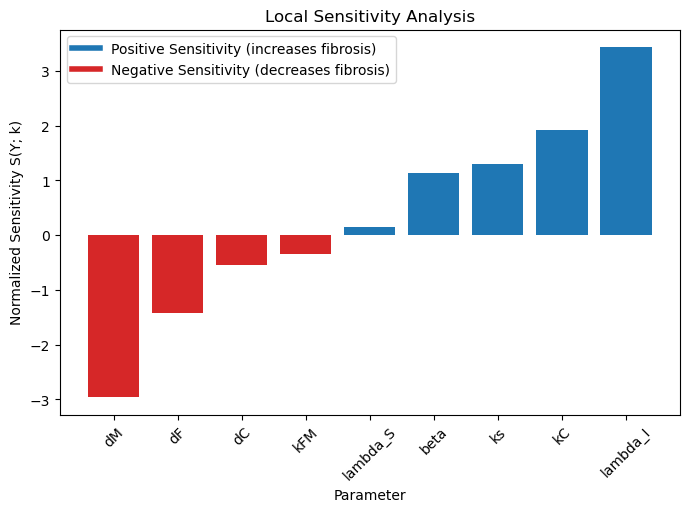

In [7]:
# ----------------------------------------------------
# Simulation setup
# ----------------------------------------------------

y0 = [0.01, 0.0, 0.01, 0.0]  # F, M, C, P
t = np.linspace(0, 30, 1000)


def run_simulation(pulse_times=None, amp=None, width=None):

    results = odeint(
        cardiac_bistable_ode,
        y0,
        t,
        args=(params, pulse_times, amp, width)
    )

    F = results[:,0]
    M = results[:,1]
    C = results[:,2]
    P = results[:,3]

    S = params['ks'] * C + (params['S0'] + params['ks'] * C) ** params['beta']
    S = normalize(S)

    I = np.array([get_pulse(tt, pulse_times, amp, width) for tt in t])

    return F, M, C, S, I, P


# ----------------------------------------------------
# Sensitivity analysis
# ----------------------------------------------------

def sensitivity_numerical(param_name, base_params, y0, t, delta=0.1):

    p_up = base_params.copy()
    p_down = base_params.copy()

    k = base_params[param_name]
    dp = delta * k

    p_up[param_name] = k + dp/2
    p_down[param_name] = k - dp/2

    res_up = odeint(cardiac_bistable_ode, y0, t, args=(p_up,))
    res_down = odeint(cardiac_bistable_ode, y0, t, args=(p_down,))
    res_base = odeint(cardiac_bistable_ode, y0, t, args=(base_params,))

    Y_up = res_up[:,2][-1]
    Y_down = res_down[:,2][-1]
    Y_base = res_base[:,2][-1]

    S = (Y_up - Y_down) / (dp * Y_base) * k

    return S


# parameters to test
parameters_to_test = [
    'lambda_I',
    'lambda_S',
    'dF',
    'kFM',
    'beta',
    'dM',
    'kC',
    'dC',
    'ks',
    'kP_F',
    'kP_I',
    'dP'
]


sensitivities = []

for par in parameters_to_test:

    S = sensitivity_numerical(par, params, y0, t)
    sensitivities.append(S)

    print(f"Sensitivity S({par}) = {S:.3f}")


# ----------------------------------------------------
# Plot sensitivity
# ----------------------------------------------------

sorted_indices = np.argsort(sensitivities)

# remove 0 sensitivity parameters
nonzero_indices = [i for i in sorted_indices if round(sensitivities[i], 3) != 0.000]
sorted_indices = nonzero_indices
parameters_sorted = [parameters_to_test[i] for i in sorted_indices]
sensitivities_sorted = [sensitivities[i] for i in sorted_indices]

colors = ['tab:red' if s < 0 else 'tab:blue' for s in sensitivities_sorted]

plt.figure(figsize=(8,5))

plt.bar(parameters_sorted, sensitivities_sorted, color=colors)

plt.ylabel("Normalized Sensitivity S(Y; k)")
plt.xlabel("Parameter")
plt.title("Local Sensitivity Analysis")

plt.legend(handles=[
    plt.Line2D([0], [0], color='tab:blue', lw=4,
               label='Positive Sensitivity (increases fibrosis)'),
    plt.Line2D([0], [0], color='tab:red', lw=4,
               label='Negative Sensitivity (decreases fibrosis)')
])

plt.xticks(rotation=45)
plt.grid(alpha=0)

plt.savefig('./figures/fig_sensitivity_analysis.png',
            dpi=300, bbox_inches='tight')

plt.show()